# SynthNet Classifier
## Introduction
On the rise is the use of Machine Learning for network management, especially for bandwidth management and Quality of Service enforcement. As the complexity of networks continues to grow, especially campus networks, the need for dynamic bandwidth management becomes ever more necessary.

The SynthNet classifier is a machine learning based traffic classification system designed to distinguish different traffic types using statistical features extracted from network flows. By learning from the labelled ISCX2016 labelled traffic data, the classifier predicts the application or traffic category of new network flows, enabling smarter Quality of Service (QoS) policies, improved bandwidth allocation, and enhanced network visibility.



In [1]:
import pandas as pd
from scipy.io import arff

# 1. Load the arff file
data, meta = arff.loadarff('/kaggle/input/datasets/guyokana/iscx30snonvpn/TimeBasedFeatures-Dataset-30s-NO-VPN.arff')

# 2. Convert it into a standard Pandas DataFrame
df = pd.DataFrame(data)

# 3. Clean up the byte strings (removes the b' prefix from text columns)
for col in df.select_dtypes(include=['object']).columns:
    df[col] = df[col].str.decode('utf-8')

# Print out all column names 
print(df.columns.tolist())

print("Categories inside 'class1':")

print(df['class1'].unique())

['duration', 'total_fiat', 'total_biat', 'min_fiat', 'min_biat', 'max_fiat', 'max_biat', 'mean_fiat', 'mean_biat', 'flowPktsPerSecond', 'flowBytesPerSecond', 'min_flowiat', 'max_flowiat', 'mean_flowiat', 'std_flowiat', 'min_active', 'mean_active', 'max_active', 'std_active', 'min_idle', 'mean_idle', 'max_idle', 'std_idle', 'class1']
Categories inside 'class1':
['BROWSING' 'CHAT' 'FT' 'MAIL' 'P2P' 'STREAMING' 'VOIP']


In [2]:
# 1. Check basic info
print("="*60)
print("DATASET INFO")
print("="*60)
print(f"Shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")

# 2. Check the target variable
print("\n" + "="*60)
print("TARGET VARIABLE ('class1')")
print("="*60)
print(f"Unique values: {df['class1'].unique()}")
print(f"Count per class:\n{df['class1'].value_counts()}")

# 3. Check for missing values
print("\n" + "="*60)
print("MISSING VALUES")
print("="*60)
print(df.isnull().sum().sum())

# 4. Check data types
print("\n" + "="*60)
print("DATA TYPES")
print("="*60)
print(df.dtypes.value_counts())

# 5. Check if there's another column with traffic types
print("\n" + "="*60)
print("OTHER POTENTIAL LABEL COLUMNS")
print("="*60)
# Columns that might contain application names or traffic types
potential_label_cols = [col for col in df.columns if any(keyword in col.lower() 
                       for keyword in ['class', 'label', 'type', 'app', 'category'])]
print(f"Potential label columns: {potential_label_cols}")

# If 'class1' is the only label, show sample
print("\n" + "="*60)
print("SAMPLE DATA (First 5 rows)")
print("="*60)
print(df.head())

DATASET INFO
Shape: (6917, 24)

Columns: ['duration', 'total_fiat', 'total_biat', 'min_fiat', 'min_biat', 'max_fiat', 'max_biat', 'mean_fiat', 'mean_biat', 'flowPktsPerSecond', 'flowBytesPerSecond', 'min_flowiat', 'max_flowiat', 'mean_flowiat', 'std_flowiat', 'min_active', 'mean_active', 'max_active', 'std_active', 'min_idle', 'mean_idle', 'max_idle', 'std_idle', 'class1']

TARGET VARIABLE ('class1')
Unique values: ['BROWSING' 'CHAT' 'FT' 'MAIL' 'P2P' 'STREAMING' 'VOIP']
Count per class:
class1
BROWSING     2500
VOIP         1438
P2P          1000
FT            961
CHAT          595
STREAMING     342
MAIL           81
Name: count, dtype: int64

MISSING VALUES
0

DATA TYPES
float64    23
object      1
Name: count, dtype: int64

OTHER POTENTIAL LABEL COLUMNS
Potential label columns: ['class1']

SAMPLE DATA (First 5 rows)
     duration  total_fiat  total_biat  min_fiat  min_biat   max_fiat  \
0  29999857.0  29999857.0  29975545.0       1.0       0.0  1014690.0   
1  29882813.0  29882777.0

## Data Description
### Shape
The ISCX 30 seconds Non-VPN dataset contains 6917 rows and 24 columns.

### Feature Overview
The dataset comprises 23 numerical features and 1 categorical feature, capturing various network traffic characteristics over 30-second intervals. These features include flow statistics (duration, packet counts) and statistical measures (mean time, max time, minimum time).

### Target variable
The target column contains 7 unique traffic classes, representing different types of network activity:

| Traffic Type  	| Count |	Percentage |
|-------------------|-------|--------------|
| BROWSING          | 2,500	|     36.14%   |
| VOIP              | 1,438	|     20.79%   |
| P2P               | 1,000	|     14.46%   |
| FT (File Transfer)|   961 |	  13.89%   |
| CHAT	            |   595 |	   8.60%   |
| STREAMING         |   342 |	   4.94%   |
| MAIL              |	 81	|      1.17%   |
| Total             | 6,917 |	 100.00%   |

#### Class Imbalance Note
The dataset exhibits significant class imbalance, with:

* Majority class: Browsing, 36.14% of samples
* Minority classes: Mail (1.17%), Streaming (4.94%) and Chat (8.60%)

This imbalance should be considered during training.

### Data Quality
No missing values, all cells contain complete data.

### Dataset Split
Given the class imbalance, use stratified sampling.





## Data Preprocessing

* Perform feature target separation.
* Encode the target, convert categorical target labels to numeric values.
* Stratify the train-test split, maintain same class distribution in both train and test sets as in the original data.
* Class mapping


In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

#Define active/idle features
active_idle = ['min_active', 'mean_active', 'max_active', 'std_active', 
               'min_idle', 'mean_idle', 'max_idle', 'std_idle']

#separate features and target
X = df.drop('class1', axis=1)
X = X.drop(columns=active_idle)
y = df['class1']

#Encode target labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

#Stratified train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

class_mapping = {
    0: 'BROWSING',
    1: 'CHAT',
    2: 'FT',
    3: 'MAIL',
    4: 'P2P',
    5: 'STREAMING',
    6: 'VOIP'
}

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

print("\nRemaining Features:")
for col in X.columns:
    print(f"  - {col}")
    
print("\nTraining class distribution:")
for code, proportion in pd.Series(y_train).value_counts(normalize=True).items():
    print(f"{class_mapping[code]}: {proportion*100:.2f}%")

Training set: 5533 samples
Test set: 1384 samples

Remaining Features:
  - duration
  - total_fiat
  - total_biat
  - min_fiat
  - min_biat
  - max_fiat
  - max_biat
  - mean_fiat
  - mean_biat
  - flowPktsPerSecond
  - flowBytesPerSecond
  - min_flowiat
  - max_flowiat
  - mean_flowiat
  - std_flowiat

Training class distribution:
BROWSING: 36.15%
VOIP: 20.78%
P2P: 14.46%
FT: 13.90%
CHAT: 8.60%
STREAMING: 4.93%
MAIL: 1.17%


## Feature Selection



* Identifies the 15 most important features in the dataset.
* Visualizes the top 15 features in a bar chart.

Top 10 selected features:
['duration', 'total_fiat', 'total_biat', 'min_fiat', 'min_biat', 'max_fiat', 'max_biat', 'mean_biat', 'max_flowiat', 'mean_flowiat']


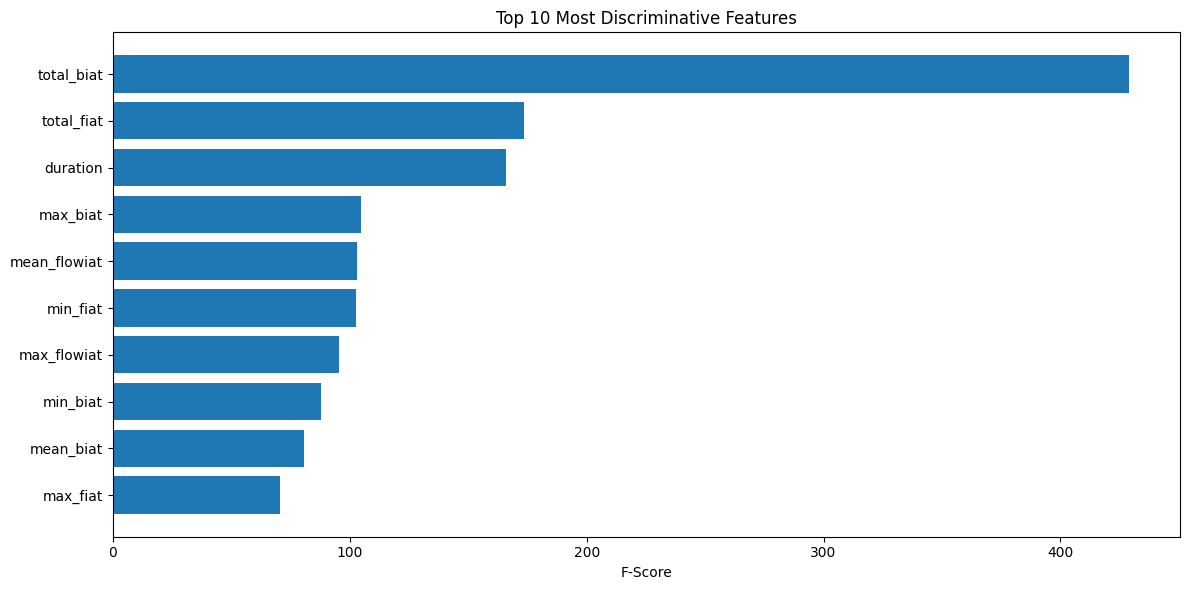

In [4]:
from sklearn.feature_selection import SelectKBest, f_classif
import matplotlib.pyplot as plt
import numpy as np

selector = SelectKBest(f_classif, k=10) #Chooses best 15 features
X_train_selected = selector.fit_transform(X_train, y_train)
X_test_selected = selector.transform(X_test)

selected_indices = selector.get_support(indices=True)
selected_features = X.columns[selected_indices]
print("Top 10 selected features:")
print(selected_features.tolist())

# Feature importance visualization
feature_scores = selector.scores_
feature_names = X.columns
feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Score': feature_scores
}).sort_values('Score', ascending=False)

plt.figure(figsize=(12, 6))
plt.barh(feature_importance['Feature'][:10], feature_importance['Score'][:10])
plt.xlabel('F-Score')
plt.title('Top 10 Most Discriminative Features')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Model Training
### Random Forest
Appropriate for imbalanced, tabular data. 
RF was the baseline model due to its: 
* Robustness to class imbalance (via class_weight='balanced')
* Built-in feature importance for interpretability
* Strong performance on tabular data

In [5]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, f1_score

# Initialize with class balancing
rf_model = RandomForestClassifier(
    n_estimators=100, 
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

# Train (no scaling needed)
rf_model.fit(X_train_selected, y_train)

# Predict
y_pred_rf = rf_model.predict(X_test_selected)

# Evaluate
print("="*60)
print("RANDOM FOREST PERFORMANCE")
print("="*60)
print(classification_report(y_test, y_pred_rf, target_names=label_encoder.classes_))
print(f"Macro F1-Score: {f1_score(y_test, y_pred_rf, average='macro'):.4f}")

RANDOM FOREST PERFORMANCE
              precision    recall  f1-score   support

    BROWSING       0.90      0.97      0.93       500
        CHAT       0.87      0.71      0.78       119
          FT       0.84      0.84      0.84       192
        MAIL       0.73      0.69      0.71        16
         P2P       0.91      0.90      0.91       200
   STREAMING       0.80      0.70      0.74        69
        VOIP       1.00      0.97      0.98       288

    accuracy                           0.90      1384
   macro avg       0.86      0.82      0.84      1384
weighted avg       0.90      0.90      0.90      1384

Macro F1-Score: 0.8418


### XGBoost with Class Weights
The second model is optimized gradient boosting algorithm known for:
* Superior performance on tabular data
* Built-in regularization to prevent overfitting
* Efficient handling of class imbalance via sample weights
* Fast training and high predictive accuracy

In [6]:
from xgboost import XGBClassifier
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, f1_score
import numpy as np

# Calculate class weights
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
weight_dict = dict(zip(np.unique(y_train), class_weights))

xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42
)

# For multi-class, use sample weights
sample_weights = np.array([weight_dict[cls] for cls in y_train])
xgb_model.fit(X_train_selected, y_train, sample_weight=sample_weights)
y_pred_xgb = xgb_model.predict(X_test_selected)

print("\n" + "="*60)
print("XGBOOST PERFORMANCE")
print("="*60)
print(classification_report(y_test, y_pred_xgb, target_names=label_encoder.classes_))
print(f"Macro F1-Score: {f1_score(y_test, y_pred_xgb, average='macro'):.4f}")


XGBOOST PERFORMANCE
              precision    recall  f1-score   support

    BROWSING       0.94      0.94      0.94       500
        CHAT       0.80      0.85      0.82       119
          FT       0.84      0.82      0.83       192
        MAIL       0.67      0.75      0.71        16
         P2P       0.92      0.91      0.91       200
   STREAMING       0.69      0.75      0.72        69
        VOIP       1.00      0.97      0.98       288

    accuracy                           0.90      1384
   macro avg       0.84      0.86      0.84      1384
weighted avg       0.91      0.90      0.91      1384

Macro F1-Score: 0.8450


### LightGBM with SMOTE

Implement LightGBM with SMOTE to address class imbalance.
SMOTE generates synthetic samples for minority classes to balance the dataset.

In [7]:
import warnings
warnings.filterwarnings('ignore', category=UserWarning, module='sklearn')

from imblearn.over_sampling import SMOTE
from lightgbm import LGBMClassifier
from imblearn.pipeline import Pipeline as ImbPipeline

# Build pipeline with SMOTE
smote_pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('classifier', LGBMClassifier(
        n_estimators=100,
        random_state=42,
        class_weight='balanced'
    ))
])

# Train (no scaling needed)
smote_pipeline.fit(X_train_selected, y_train)
y_pred_lgbm = smote_pipeline.predict(X_test_selected)

print("\n" + "="*60)
print("SMOTE + LIGHTGBM PERFORMANCE")
print("="*60)
print(classification_report(y_test, y_pred_lgbm, target_names=label_encoder.classes_))
print(f"Macro F1-Score: {f1_score(y_test, y_pred_lgbm, average='macro'):.4f}")

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002697 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2550
[LightGBM] [Info] Number of data points in the train set: 14000, number of used features: 10
[LightGBM] [Info] Start training from score -1.945910
[LightGBM] [Info] Start training from score -1.945910
[LightGBM] [Info] Start training from score -1.945910
[LightGBM] [Info] Start training from score -1.945910
[LightGBM] [Info] Start training from score -1.945910
[LightGBM] [Info] Start training from score -1.945910
[LightGBM] [Info] Start training from score -1.945910

SMOTE + LIGHTGBM PERFORMANCE
              precision    recall  f1-score   support

    BROWSING       0.94      0.95      0.95       500
        CHAT       0.77      0.85      0.81       119
          FT       0.85      0.80      0.82       192
        MAIL       0.54      0.88      0.67        16
         P2P       0.92      0.9

## Model Comparison

Evaluate and compare the performance of all three models using the same 15 selected features and stratified test set. 

Key metrics include Accuracy, Macro F1 (treating all classes equally), Weighted F1 (accounting for class imbalance), and Training Time to balance performance with efficiency.

In [8]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Dictionary to store results
results = {
    'Model': ['Random Forest', 'XGBoost', 'SMOTE+LightGBM'],
    'Accuracy': [],
    'Macro F1': [],
    'Weighted F1': [],
    'Training Time (s)': []
}

import time

# Random Forest
start = time.time()
rf_model.fit(X_train_selected, y_train)
results['Training Time (s)'].append(time.time() - start)
y_pred_rf = rf_model.predict(X_test_selected)
results['Accuracy'].append(accuracy_score(y_test, y_pred_rf))
results['Macro F1'].append(f1_score(y_test, y_pred_rf, average='macro'))
results['Weighted F1'].append(f1_score(y_test, y_pred_rf, average='weighted'))

# XGBoost
start = time.time()
xgb_model.fit(X_train_selected, y_train, sample_weight=sample_weights)
results['Training Time (s)'].append(time.time() - start)
y_pred_xgb = xgb_model.predict(X_test_selected)
results['Accuracy'].append(accuracy_score(y_test, y_pred_xgb))
results['Macro F1'].append(f1_score(y_test, y_pred_xgb, average='macro'))
results['Weighted F1'].append(f1_score(y_test, y_pred_xgb, average='weighted'))

# SMOTE+LightGBM
start = time.time()
smote_pipeline.fit(X_train_selected, y_train)
results['Training Time (s)'].append(time.time() - start)
y_pred_lgbm = smote_pipeline.predict(X_test_selected)
results['Accuracy'].append(accuracy_score(y_test, y_pred_lgbm))
results['Macro F1'].append(f1_score(y_test, y_pred_lgbm, average='macro'))
results['Weighted F1'].append(f1_score(y_test, y_pred_lgbm, average='weighted'))

# Create comparison dataframe
comparison_df = pd.DataFrame(results)
print("="*60)
print("MODEL COMPARISON (No Feature Scaling)")
print("="*60)
print(comparison_df)

# Select best model
best_model_idx = comparison_df['Macro F1'].idxmax()
best_model_name = comparison_df.loc[best_model_idx, 'Model']
print(f"\n✅ Best performing model: {best_model_name}")
print(f"   Macro F1: {comparison_df.loc[best_model_idx, 'Macro F1']:.4f}")
print(f"   Training Time: {comparison_df.loc[best_model_idx, 'Training Time (s)']:.2f}s")

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000806 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2550
[LightGBM] [Info] Number of data points in the train set: 14000, number of used features: 10
[LightGBM] [Info] Start training from score -1.945910
[LightGBM] [Info] Start training from score -1.945910
[LightGBM] [Info] Start training from score -1.945910
[LightGBM] [Info] Start training from score -1.945910
[LightGBM] [Info] Start training from score -1.945910
[LightGBM] [Info] Start training from score -1.945910
[LightGBM] [Info] Start training from score -1.945910
MODEL COMPARISON (No Feature Scaling)
            Model  Accuracy  Macro F1  Weighted F1  Training Time (s)
0   Random Forest  0.902457  0.841825     0.900729           0.818837
1         XGBoost  0.904624  0.844960     0.905532           1.146018
2  SMOTE+LightGBM  0.903179  0.834906     0.904474           1.279421

✅ Best perform

## Save model for production

In [9]:
import joblib
import json
import numpy as np
import os

# Create working directory if needed
os.makedirs('/kaggle/working', exist_ok=True)

# 1. Save the winning model (XGBoost)
joblib.dump(xgb_model, '/kaggle/working/traffic_classifier.pkl')
print("✅ Saved: traffic_classifier.pkl")

# 2. Save label encoder (for reference, though you'll hardcode)
joblib.dump(label_encoder, '/kaggle/working/label_encoder.pkl')
print("✅ Saved: label_encoder.pkl")

# 3. Save feature selector (KEEP THIS - don't hardcode)
joblib.dump(selector, '/kaggle/working/feature_selector.pkl')
print("✅ Saved: feature_selector.pkl")

# 4. Save the selected feature names (for Ryu controller)
selected_features = X.columns[selector.get_support(indices=True)].tolist()
with open('/kaggle/working/selected_features.json', 'w') as f:
    json.dump(selected_features, f)
print(f"✅ Saved: selected_features.json ({len(selected_features)} features)")

# 5. Save label map (hardcode this in FastAPI)
label_map = {
    0: 'BROWSING', 1: 'CHAT', 2: 'FT', 3: 'MAIL',
    4: 'P2P', 5: 'STREAMING', 6: 'VOIP'
}
with open('/kaggle/working/label_map.json', 'w') as f:
    json.dump(label_map, f)
print("✅ Saved: label_map.json")

# 6. Save full feature list (all 15 features for Ryu reference)
all_features = X.columns.tolist()
with open('/kaggle/working/all_features.json', 'w') as f:
    json.dump(all_features, f)
print(f"✅ Saved: all_features.json ({len(all_features)} features)")

# 7. Verify all files exist
print("\n📦 Saved Files:")
for file in os.listdir('/kaggle/working/'):
    if file.endswith(('.pkl', '.json')):
        size = os.path.getsize(f'/kaggle/working/{file}') / 1024
        print(f"  - {file} ({size:.1f} KB)")

✅ Saved: traffic_classifier.pkl
✅ Saved: label_encoder.pkl
✅ Saved: feature_selector.pkl
✅ Saved: selected_features.json (10 features)
✅ Saved: label_map.json
✅ Saved: all_features.json (15 features)

📦 Saved Files:
  - label_map.json (0.1 KB)
  - label_encoder.pkl (0.5 KB)
  - all_features.json (0.2 KB)
  - selected_features.json (0.1 KB)
  - feature_selector.pkl (1.1 KB)
  - traffic_classifier.pkl (1603.2 KB)
